# RGB Multiclass Fault Classifier — EfficientNet-B1

**Ground station laptop component**  
**4-class classification**: Soiling, Shadowing, Burn/Discoloration, Structural Damage

**Input**: CLAHE-preprocessed RGB panel crops (already filtered by edge binary classifier)

Designed to run on **Kaggle GPU** (T4 x2 or P100)

In [1]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchvision.transforms import functional as TF
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import cv2
from PIL import Image

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# ─────────────────────────────────────────────
# REPRODUCIBILITY
# ─────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"✅ Reproducibility set with seed = {SEED}")

✅ Reproducibility set with seed = 42


In [3]:
# ─────────────────────────────────────────────
# FINAL CONFIG
# ─────────────────────────────────────────────
CONFIG = {
    "data_dir": "/kaggle/input/datasets/chellalaicha/unified-dataset/unified_dataset",  
    "output_dir": "/kaggle/working/rgb_multiclass_final",
    "num_classes": 4,
    "class_names": ["Soiling_Pollution", "Shadowing_Vegetation", 
                    "Burn_Discoloration", "Structural_Damage"],
    "img_size": 240,
    "batch_size": 32,
    "num_epochs": 100,
    "lr_backbone": 5e-5,
    "lr_head": 1e-3,
    "weight_decay": 1e-4,
    "patience": 30,
    "unfreeze_epoch": 5,
    "full_unfreeze_epoch": 15,
    "num_workers": 4,
}

os.makedirs(CONFIG["output_dir"], exist_ok=True)

print("✅ Final Configuration Loaded")
print(f"   Head LR     : {CONFIG['lr_head']}")
print(f"   Epochs      : {CONFIG['num_epochs']}")
print(f"   Patience    : {CONFIG['patience']}")

✅ Final Configuration Loaded
   Head LR     : 0.001
   Epochs      : 100
   Patience    : 30


In [4]:
# ─────────────────────────────────────────────
# CLAHE TRANSFORM (matches edge device preprocessing)
# ─────────────────────────────────────────────
class CLAHETransform:
    """Apply CLAHE to PIL image — must match Pi preprocessing exactly."""
    def __init__(self, clip_limit=2.0, tile_grid=(8, 8)):
        self.clip_limit = clip_limit
        self.tile_grid = tile_grid
    
    def __call__(self, img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=self.clip_limit, tileGridSize=self.tile_grid)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        img_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_clahe)

print("✅ CLAHETransform class defined successfully")

✅ CLAHETransform class defined successfully


In [5]:

IMG_SIZE = CONFIG["img_size"]
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 48, IMG_SIZE + 48)),
    CLAHETransform(clip_limit=3.0, tile_grid=(8, 8)),
    transforms.RandomCrop(IMG_SIZE, padding=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(40),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15), shear=15),
    transforms.ColorJitter(brightness=0.45, contrast=0.45, saturation=0.35, hue=0.12),
    transforms.RandAugment(num_ops=3, magnitude=11),   # even stronger
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    CLAHETransform(clip_limit=2.0, tile_grid=(8, 8)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("✅ Stronger train-only augmentation ready")


✅ Stronger train-only augmentation ready


In [6]:
# ─────────────────────────────────────────────
# FIXED build_datasets — Stratified Split on ORIGINAL images
# ─────────────────────────────────────────────
def build_datasets(data_dir):
    full_dataset = datasets.ImageFolder(root=data_dir)
    
    # Keep only the 4 anomaly classes
    anomaly_class_names = [c for c in full_dataset.classes if not c.startswith("Class_0")]
    
    samples = []
    for path, label_idx in full_dataset.samples:
        class_name = full_dataset.classes[label_idx]
        if class_name in anomaly_class_names:
            new_label = anomaly_class_names.index(class_name)
            samples.append((path, new_label))
    
    print(f"✅ Original anomaly samples: {len(samples)}")
    for i, name in enumerate(anomaly_class_names):
        count = sum(1 for _, lbl in samples if lbl == i)
        print(f"   [{i}] {name}: {count} images")
    
    # Stratified split (70% / 15% / 15%)
    from sklearn.model_selection import train_test_split
    
    train_samples, temp = train_test_split(
        samples, 
        test_size=0.30, 
        stratify=[lbl for _, lbl in samples], 
        random_state=42
    )
    
    val_samples, test_samples = train_test_split(
        temp, 
        test_size=0.50, 
        stratify=[lbl for _, lbl in temp], 
        random_state=42
    )
    
    print(f"\n✅ Stratified split completed:")
    print(f"   Train samples : {len(train_samples)}")
    print(f"   Val samples   : {len(val_samples)}")
    print(f"   Test samples  : {len(test_samples)}")
    
    def print_class_dist(samples, name):
        counts = np.bincount([lbl for _, lbl in samples])
        print(f"\n{name} class distribution:")
        for i, cls_name in enumerate(anomaly_class_names):
            print(f"   [{i}] {cls_name}: {counts[i]} images")
    
    print_class_dist(train_samples, "Train")
    print_class_dist(val_samples, "Val")
    print_class_dist(test_samples, "Test")
    
    return train_samples, val_samples, test_samples, anomaly_class_names

# Custom Dataset class
class SampleListDataset(torch.utils.data.Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

print("✅ Dataset preparation functions defined")

✅ Dataset preparation functions defined


In [7]:
# ─────────────────────────────────────────────
# LEAKAGE CHECK — Verify no image appears in more than one split
# ─────────────────────────────────────────────
def check_image_leakage(train_samples, val_samples, test_samples):
    # Extract just the filename (or full path) to identify unique images
    def get_image_id(path):
        return os.path.basename(path)          # filename only (safest)
        # return path                              # use full path if you prefer
    
    train_ids = {get_image_id(p) for p, _ in train_samples}
    val_ids   = {get_image_id(p) for p, _ in val_samples}
    test_ids  = {get_image_id(p) for p, _ in test_samples}
    
    overlap_train_val  = train_ids & val_ids
    overlap_train_test = train_ids & test_ids
    overlap_val_test   = val_ids   & test_ids
    
    print("=== IMAGE LEAKAGE CHECK (on original images) ===")
    print(f"Total unique images in Train : {len(train_ids)}")
    print(f"Total unique images in Val   : {len(val_ids)}")
    print(f"Total unique images in Test  : {len(test_ids)}")
    print(f"Overlap Train-Val  : {len(overlap_train_val)} images")
    print(f"Overlap Train-Test : {len(overlap_train_test)} images")
    print(f"Overlap Val-Test   : {len(overlap_val_test)} images")
    
    if overlap_train_val or overlap_train_test or overlap_val_test:
        print("⚠️  WARNING: Leakage detected! Some original images appear in multiple splits.")
    else:
        print("✅ No leakage detected — splits are clean and disjoint!")
        
    # Optional: show a few overlapping examples if any
    if overlap_train_val:
        print("\nExample overlapping images (Train-Val):", list(overlap_train_val)[:5])

# Run the check
train_samples, val_samples, test_samples, class_names = build_datasets(CONFIG["data_dir"])
check_image_leakage(train_samples, val_samples, test_samples)

✅ Original anomaly samples: 3381
   [0] Class_1_Soiling_pollution: 2207 images
   [1] Class_2_Shadowing_vegetation: 387 images
   [2] Class_3_Burn_Discoloration: 264 images
   [3] Class_4_Structural_damage: 523 images

✅ Stratified split completed:
   Train samples : 2366
   Val samples   : 507
   Test samples  : 508

Train class distribution:
   [0] Class_1_Soiling_pollution: 1544 images
   [1] Class_2_Shadowing_vegetation: 271 images
   [2] Class_3_Burn_Discoloration: 185 images
   [3] Class_4_Structural_damage: 366 images

Val class distribution:
   [0] Class_1_Soiling_pollution: 331 images
   [1] Class_2_Shadowing_vegetation: 58 images
   [2] Class_3_Burn_Discoloration: 40 images
   [3] Class_4_Structural_damage: 78 images

Test class distribution:
   [0] Class_1_Soiling_pollution: 332 images
   [1] Class_2_Shadowing_vegetation: 58 images
   [2] Class_3_Burn_Discoloration: 39 images
   [3] Class_4_Structural_damage: 79 images
=== IMAGE LEAKAGE CHECK (on original images) ===
Total u

In [8]:
# ─────────────────────────────────────────────
# MODEL: EfficientNet-B1
# ─────────────────────────────────────────────
def build_model(num_classes):
    model = models.efficientnet_b1(weights=models.EfficientNet_B1_Weights.IMAGENET1K_V1)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    print("✅ EfficientNet-B1 model created with dropout=0.3")
    return model


def unfreeze_layers(model, epoch):
    if epoch == CONFIG["unfreeze_epoch"]:
        for name, param in model.named_parameters():
            if any(x in name for x in ["features.5", "features.6", "features.7", "features.8", "classifier"]):
                param.requires_grad = True
        print(f"🔓 Epoch {epoch}: Unfroze later stages (features 5-8) + classifier")
    
    elif epoch == CONFIG["full_unfreeze_epoch"]:
        for param in model.parameters():
            param.requires_grad = True
        print(f"🔓 Epoch {epoch}: FULL backbone unfrozen - all layers trainable")

print("✅ Model + staged unfreezing functions ready")

✅ Model + staged unfreezing functions ready


In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.alpha = alpha  # can be None or a tensor of shape (num_classes)

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        # Apply class weights if provided
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss

print("✅ FocalLoss with class weighting support ready")

def get_optimizer(model):
    # Group parameters
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "classifier" in name or "features.8" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    
    optimizer = optim.AdamW([
        {'params': backbone_params, 'lr': CONFIG["lr_backbone"]},
        {'params': head_params,     'lr': CONFIG["lr_head"]},
    ], weight_decay=CONFIG["weight_decay"])
    
    print(f"✅ Optimizer ready → Backbone LR: {CONFIG['lr_backbone']}, Head LR: {CONFIG['lr_head']}")
    return optimizer

✅ FocalLoss with class weighting support ready


In [10]:
# ─────────────────────────────────────────────
# TRAINING & EVALUATION FUNCTIONS
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    
    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return running_loss / total, correct / total, all_preds, all_labels

print("✅ Training and evaluation functions defined")

✅ Training and evaluation functions defined


🚀 Starting training on cuda
✅ Original anomaly samples: 3381
   [0] Class_1_Soiling_pollution: 2207 images
   [1] Class_2_Shadowing_vegetation: 387 images
   [2] Class_3_Burn_Discoloration: 264 images
   [3] Class_4_Structural_damage: 523 images

✅ Stratified split completed:
   Train samples : 2366
   Val samples   : 507
   Test samples  : 508

Train class distribution:
   [0] Class_1_Soiling_pollution: 1544 images
   [1] Class_2_Shadowing_vegetation: 271 images
   [2] Class_3_Burn_Discoloration: 185 images
   [3] Class_4_Structural_damage: 366 images

Val class distribution:
   [0] Class_1_Soiling_pollution: 331 images
   [1] Class_2_Shadowing_vegetation: 58 images
   [2] Class_3_Burn_Discoloration: 40 images
   [3] Class_4_Structural_damage: 78 images

Test class distribution:
   [0] Class_1_Soiling_pollution: 332 images
   [1] Class_2_Shadowing_vegetation: 58 images
   [2] Class_3_Burn_Discoloration: 39 images
   [3] Class_4_Structural_damage: 79 images
✅ Class weights computed: [0

100%|██████████| 30.1M/30.1M [00:00<00:00, 186MB/s]


✅ EfficientNet-B1 model created with dropout=0.3
✅ Optimizer ready → Backbone LR: 5e-05, Head LR: 0.001

                  TRAINING STARTED - Final Version


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 001/100 | Train Loss: 0.2693 Acc: 0.6124 | Val Loss: 0.1238 Acc: 0.6489 | Time: 37.6s
   → BEST MODEL SAVED! (val_acc = 0.6489)


...

Epoch 098/100 | Train Loss: 0.0127 Acc: 0.9628 | Val Loss: 0.0315 Acc: 0.9684 | Time: 33.8s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 099/100 | Train Loss: 0.0157 Acc: 0.9565 | Val Loss: 0.0320 Acc: 0.9625 | Time: 34.2s


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 100/100 | Train Loss: 0.0169 Acc: 0.9522 | Val Loss: 0.0319 Acc: 0.9625 | Time: 33.8s

                  FINAL TEST EVALUATION
Test Loss : 0.0313 | Test Accuracy : 0.9587

📊 Classification Report:
                              precision    recall  f1-score   support

   Class_1_Soiling_pollution     0.9785    0.9608    0.9696       332
Class_2_Shadowing_vegetation     0.9153    0.9310    0.9231        58
  Class_3_Burn_Discoloration     0.8667    1.0000    0.9286        39
   Class_4_Structural_damage     0.9615    0.9494    0.9554        79

                    accuracy                         0.9587       508
                   macro avg     0.9305    0.9603    0.9442       508
                weighted avg     0.9601    0.9587    0.9589       508



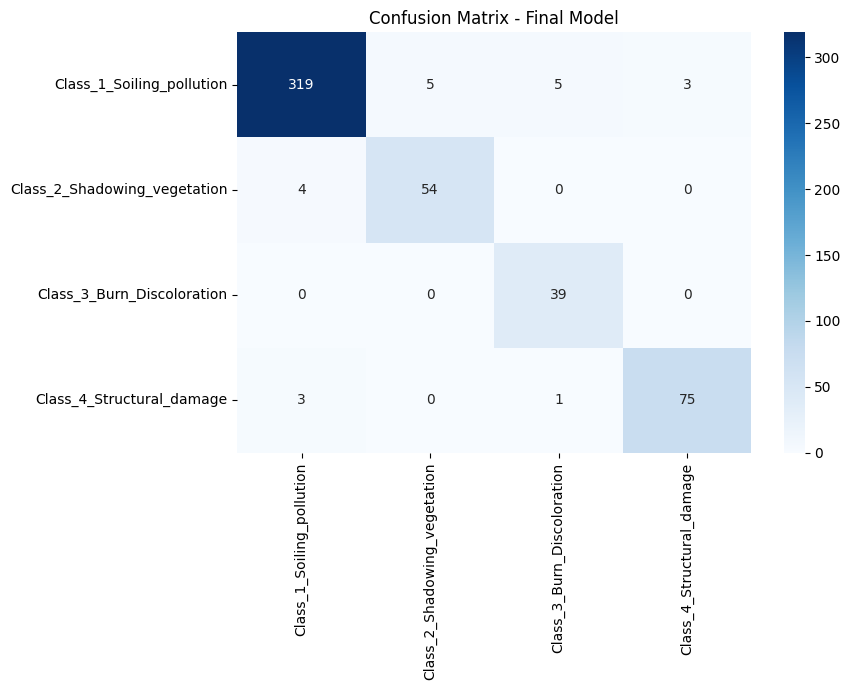

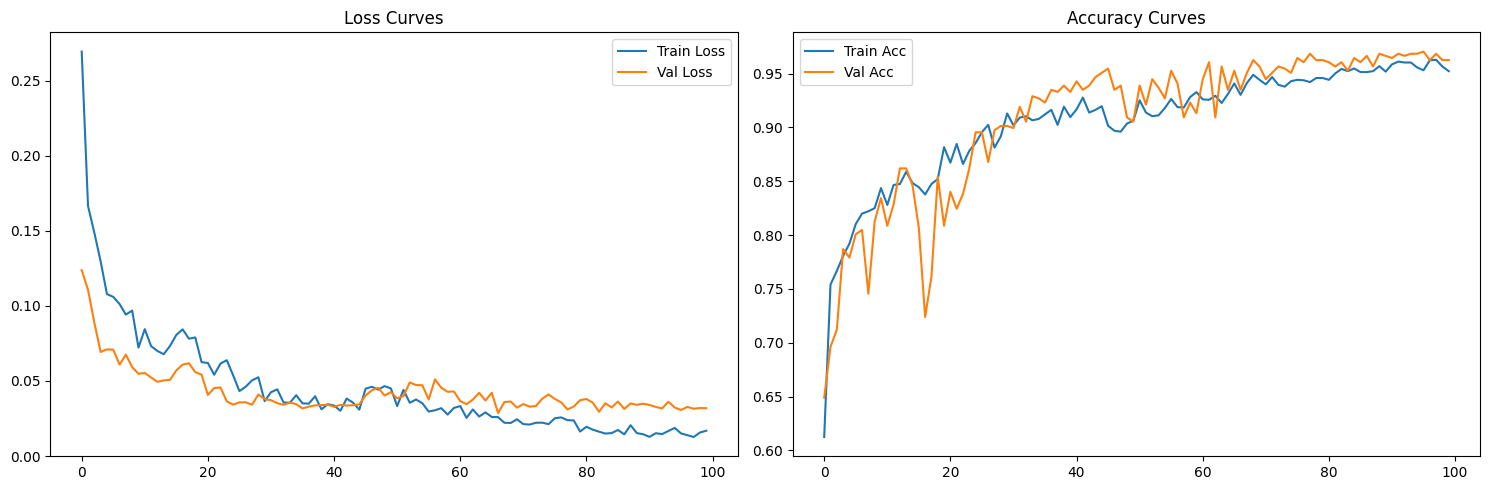


🎉 Training finished!
Best Validation Accuracy : 0.9704
Final Test Accuracy      : 0.9587
📁 All outputs saved in: /kaggle/working/rgb_multiclass_final


In [11]:
def main():
    print(f"🚀 Starting training on {device}")
    
    # Build datasets
    train_samples, val_samples, test_samples, class_names = build_datasets(CONFIG["data_dir"])

    # === NEW: Compute class weights (inverse frequency) ===
    train_labels = [lbl for _, lbl in train_samples]
    supports = np.bincount(train_labels)
    class_weights = 1.0 / (supports + 1e-6)          # avoid division by zero
    class_weights = class_weights / class_weights.sum() * CONFIG["num_classes"]  # normalize
    class_weights = torch.tensor(class_weights, dtype=torch.float32)
    print("✅ Class weights computed:", class_weights.tolist())
    
    # DataLoaders
    train_ds = SampleListDataset(train_samples, transform=train_transforms)
    val_ds   = SampleListDataset(val_samples,   transform=val_transforms)
    test_ds  = SampleListDataset(test_samples,  transform=val_transforms)
    
    # Weighted sampler (still useful even with Focal Loss)
    train_labels = [l for _, l in train_samples]
    sampler = WeightedRandomSampler(1.0 / np.bincount(train_labels)[train_labels],
                                    num_samples=len(train_labels), replacement=True)
    
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler,
                              num_workers=CONFIG["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                            num_workers=CONFIG["num_workers"], pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False,
                             num_workers=CONFIG["num_workers"], pin_memory=True)
    
    print(f"✅ DataLoaders created | Train batches: {len(train_loader)} | Val/Test batches: {len(val_loader)}")
    
    # Model + Optimizer
    model = build_model(CONFIG["num_classes"]).to(device)
    optimizer = get_optimizer(model)
    
    # Use the weighted FocalLoss we just updated
    criterion = FocalLoss(alpha=class_weights.to(device), gamma=2.5).to(device)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=15, T_mult=2, eta_min=1e-6
    )
    
    best_val_acc = 0.0
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    print("\n" + "="*80)
    print("                  TRAINING STARTED - Final Version")
    print("="*80)
    
    for epoch in range(1, CONFIG["num_epochs"] + 1):
        unfreeze_layers(model, epoch)
        
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        scheduler.step()
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        elapsed = time.time() - t0
        
        print(f"Epoch {epoch:03d}/{CONFIG['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"Time: {elapsed:.1f}s")
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), f"{CONFIG['output_dir']}/best_rgb_multiclass_final.pt")
            print(f"   → BEST MODEL SAVED! (val_acc = {val_acc:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["patience"]:
                print(f"⏹️ Early stopping triggered at epoch {epoch}")
                break
    
    # Final Test
    print("\n" + "="*60)
    print("                  FINAL TEST EVALUATION")
    print("="*60)
    
    model.load_state_dict(torch.load(f"{CONFIG['output_dir']}/best_rgb_multiclass_final.pt"))
    test_loss, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)
    
    print(f"Test Loss : {test_loss:.4f} | Test Accuracy : {test_acc:.4f}")
    print("\n📊 Classification Report:")
    print(classification_report(labels, preds, target_names=class_names, digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title("Confusion Matrix - Final Model")
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/confusion_matrix_final.png", dpi=200)
    plt.show()
    
    # Training Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Val Loss")
    ax1.set_title("Loss Curves")
    ax1.legend()
    
    ax2.plot(history["train_acc"], label="Train Acc")
    ax2.plot(history["val_acc"], label="Val Acc")
    ax2.set_title("Accuracy Curves")
    ax2.legend()
    plt.tight_layout()
    plt.savefig(f"{CONFIG['output_dir']}/training_curves_final.png", dpi=200)
    plt.show()
    
    print(f"\n🎉 Training finished!")
    print(f"Best Validation Accuracy : {best_val_acc:.4f}")
    print(f"Final Test Accuracy      : {test_acc:.4f}")
    print(f"📁 All outputs saved in: {CONFIG['output_dir']}")

if __name__ == "__main__":
    main()